In [2]:
SERVER = r"localhost\SQLEXPRESS"
DATABASE = "SupplyChainAnalytics"

connection_string = (
    "mssql+pyodbc://"
    f"{SERVER}/{DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

print("SQL Server connection created")

SQL Server connection created


In [1]:
%pip install sqlalchemy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

print("Libraries loaded successfully")

Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully


In [ ]:
query = """
SELECT TOP 10 *
FROM dbo.order_analytics
"""

df_test = pd.read_sql(query, engine)

df_test.head()

Load the complete analytical dataset

In [5]:
query = """
SELECT *
FROM dbo.order_analytics
"""

df = pd.read_sql(query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 99441
Columns: 40


In [6]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,campos dos goytacazes,RJ,28013,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,...,15.625694,-8.011805,1,0,0,Early,No Delay,0,0,Low Value
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,santa fe do sul,SP,15775,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,...,18.546527,-2.330555,1,0,0,Early,No Delay,0,0,Medium Value
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,para de minas,MG,35661,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,...,21.393750,-13.445138,1,0,0,Early,No Delay,0,0,Medium Value
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,atibaia,SP,12952,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,...,11.583333,-5.436111,1,0,0,Early,No Delay,0,0,Low Value
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,varzea paulista,SP,13226,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,...,40.418750,-15.304166,1,0,0,Early,No Delay,0,0,Medium Value


In [8]:
df.shape

(99441, 40)

Understand the analytical dataset

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   customer_unique_id             99441 non-null  str           
 3   order_status                   99441 non-null  str           
 4   customer_city                  99441 non-null  str           
 5   customer_state                 99441 non-null  str           
 6   customer_zip_code_prefix       99441 non-null  str           
 7   order_purchase_timestamp       99441 non-null  datetime64[us]
 8   order_approved_at              99281 non-null  datetime64[us]
 9   order_delivered_carrier_date   97658 non-null  datetime64[us]
 10  order_delivered_customer_date  96476 non-null  datetime64[us]
 11  order_estimated_delivery_d

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99441,99441,00010242fe8c5a6d1ba2dd792cb16214,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,3ce436f183e68e07877b285a838db11a,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441,14994,22790,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278,2016-10-08 10:34:01,2017-09-15 22:28:50.250000,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28,NaN


In [11]:
df.isna().sum().sort_values(ascending=False)

delay_days                       2965
fulfillment_days                 2965
order_delivered_customer_date    2965
shipping_days                    1797
order_delivered_carrier_date     1783
order_item_count                  775
seller_count                      775
product_count                     775
total_order_value                 775
order_item_value                  775
freight_value                     775
review_record_count               768
avg_review_score                  768
distinct_review_count             768
max_review_score                  768
min_review_score                  768
processing_days                   160
order_approved_at                 160
payment_type_count                  1
max_payment_installments            1
payment_record_count                1
total_payment_value                 1
customer_id                         0
order_id                            0
order_purchase_timestamp            0
customer_zip_code_prefix            0
customer_sta

Verifying the most important business grain

In [12]:
print("Total rows:", len(df))
print("Distinct orders:", df["order_id"].nunique())
print("Duplicate order rows:", df["order_id"].duplicated().sum())

Total rows: 99441
Distinct orders: 99441
Duplicate order rows: 0


Created a basic EDA summary

In [13]:
eda_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

eda_summary

,column,dtype,missing_count,missing_pct,unique_values
order_id,order_id,str,0,0.00,99441
customer_id,customer_id,str,0,0.00,99441
customer_unique_id,customer_unique_id,str,0,0.00,96096
order_status,order_status,str,0,0.00,8
customer_city,customer_city,str,0,0.00,4119
customer_state,customer_state,str,0,0.00,27
customer_zip_code_prefix,customer_zip_code_prefix,str,0,0.00,14994
order_purchase_timestamp,order_purchase_timestamp,datetime64[us],0,0.00,98875
order_approved_at,order_approved_at,datetime64[us],160,0.16,90733
order_delivered_carrier_date,order_delivered_carrier_date,datetime64[us],1783,1.79,81018


First business-level overview

In [14]:
df["order_status"].value_counts(dropna=False)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [15]:
df["delivery_performance_category"].value_counts()

delivery_performance_category
Early            88649
Late              7827
Not Delivered     2965
Name: count, dtype: int64

In [16]:
df["delay_severity"].value_counts()

delay_severity
No Delay          88649
Severe Delay       3346
Not Delivered      2965
Minor Delay        2662
Moderate Delay     1819
Name: count, dtype: int64

In [17]:
late_rate = df["is_late"].mean() * 100

print(f"Late delivery rate: {late_rate:.2f}%")

Late delivery rate: 7.87%


In [18]:
delivered_rate = df["is_delivered"].mean() * 100

print(f"Delivered rate: {delivered_rate:.2f}%")

Delivered rate: 97.02%


Delivery-time distributions

In [19]:
delivery_metrics = [
    "processing_days",
    "shipping_days",
    "fulfillment_days",
    "expected_delivery_days",
    "delay_days"
]

df[delivery_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
processing_days,99281.0,0.434162,1.084907,0.000000,0.009027,0.014583,0.607638,187.882638
shipping_days,97644.0,2.805081,3.549413,-171.218750,0.875694,1.818750,3.580555,125.762500
fulfillment_days,96476.0,12.558658,9.546533,0.533333,6.766493,10.218055,15.720138,209.628472
expected_delivery_days,99441.0,23.767991,8.832372,1.649305,18.331944,23.240972,28.425000,155.136111
delay_days,96476.0,-11.179505,10.186111,-146.016666,-16.244444,-11.949305,-6.390277,188.975000


In [20]:
df[delivery_metrics].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T

,0.01,0.25,0.50,0.75,0.95,0.99
processing_days,0.000000,0.009027,0.014583,0.607638,2.019444,3.757083
shipping_days,-0.069146,0.875694,1.818750,3.580555,8.097916,17.150791
fulfillment_days,1.824826,6.766493,10.218055,15.720138,29.275694,46.050000
expected_delivery_days,6.020694,18.331944,23.240972,28.425000,38.484722,50.422638
delay_days,-35.154687,-16.244444,-11.949305,-6.390277,3.818055,18.939236


visualizations

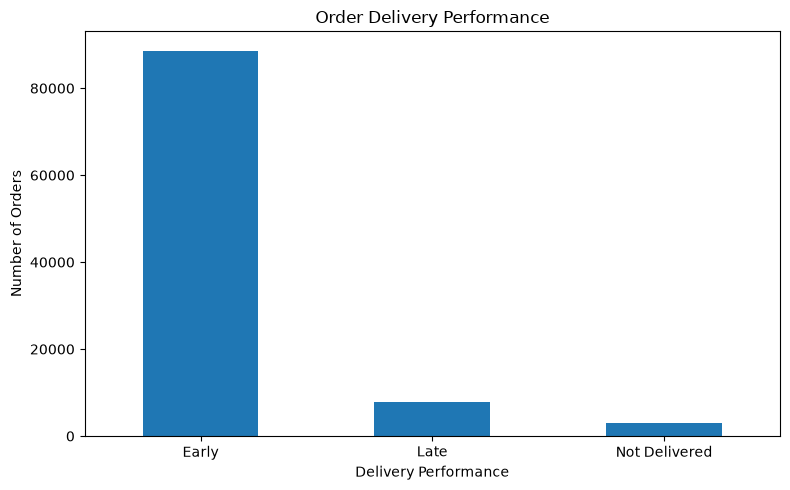

In [21]:
delivery_counts = (
    df["delivery_performance_category"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

delivery_counts.plot(kind="bar")

plt.title("Order Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

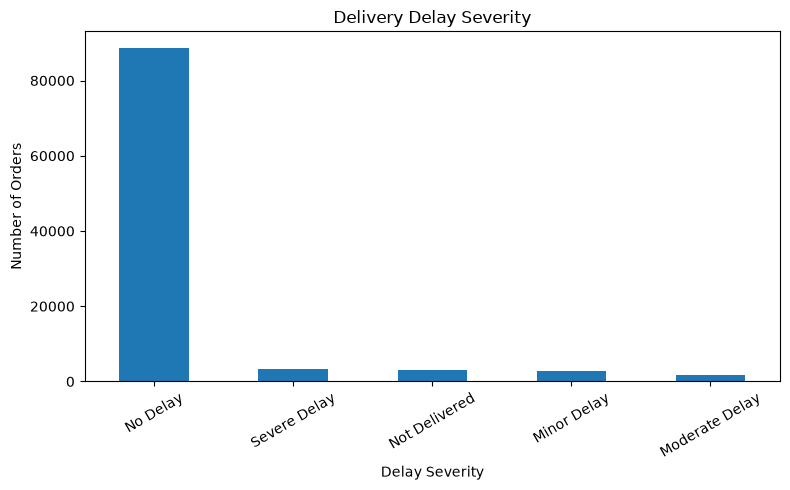

In [22]:
severity_counts = (
    df["delay_severity"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

severity_counts.plot(kind="bar")

plt.title("Delivery Delay Severity")
plt.xlabel("Delay Severity")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

root-cause exploration

In [23]:
seller_complexity = (
    df[df["is_delivered"] == 1]
    .groupby("has_multiple_sellers")
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

seller_complexity["late_rate"] *= 100

seller_complexity

,has_multiple_sellers,orders,late_orders,late_rate
0,0,95201,7809,8.202645
1,1,1275,18,1.411765


In [24]:
order_value_analysis = (
    df[df["is_delivered"] == 1]
    .groupby("order_value_bucket")
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        late_rate=("is_late", "mean"),
        avg_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

order_value_analysis["late_rate"] *= 100

order_value_analysis

,order_value_bucket,orders,late_orders,late_rate,avg_order_value
0,High Value,2967,277,9.336030,680.498652
1,Low Value,45926,3479,7.575230,60.223781
2,Medium Value,46476,3962,8.524830,191.173088
3,Very High Value,1107,109,9.846432,1580.222349


In [25]:
review_analysis = (
    df[df["is_delivered"] == 1]
    .dropna(subset=["avg_review_score"])
    .groupby("avg_review_score")
    .agg(
        orders=("order_id", "count"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

review_analysis["late_rate"] *= 100

review_analysis

,avg_review_score,orders,late_rate
0,1.000000,9316,37.924002
1,1.500000,8,12.500000
2,2.000000,2916,20.644719
3,2.500000,30,20.000000
4,3.000000,7916,10.977767
5,3.333333,1,0.000000
6,3.500000,23,13.043478
7,4.000000,18868,5.008480
8,4.333333,1,0.000000
9,4.500000,53,3.773585
